# 01 — Data Exploration

Initial look at the two CSV datasets that feed every downstream notebook
in this directory.

**Goals**

1. Verify schemas, dtypes and row counts.
2. Quantify class balance — both targets are heavily imbalanced.
3. Spot obvious leakage and exclude leaky columns from feature engineering.
4. Build intuition with distributions, correlations and time-of-day plots.

Reproducible from a fresh kernel — run all cells top to bottom.


## Imports & setup


In [1]:
import sys, pathlib
# The shared helper package lives at ml-training/src/rexell_ml.
sys.path.insert(0, str(pathlib.Path.cwd().parent / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from rexell_ml import data, features

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

data.set_seed(42)


2026-04-29 16:31:03.822345: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Master CSV — transaction-level blockchain ticketing


In [2]:
master = data.load_master()
print("rows / cols:", master.shape)
master.head()


rows / cols: (12005, 15)


,transaction_hash,wallet_address,event_id,transaction_type,status,timestamp,ticket_count,price_paid,original_event_price,markup_pct,ip_hash,is_resale,scalping_label,fraud_label,risk_score
0,0xf21f4ec6c69d4ea2a521248df1b1b3c4095ce5ba,0x4ac429ec22574039a5d1bbf8f8e3b18b,EVT_048,PURCHASE,SUCCESS,2025-11-26 20:05:23.645973,4,177.0,177,0.0,407e94601a5093b0c07491a7ab5f8533,False,0,0,0
1,0xd19086654ba747d49058bfac41f7fafebb46bee0,0xdc5c8632d1434698b31d21c1785a2d2b,EVT_048,PURCHASE,SUCCESS,2025-11-26 23:11:42.645973,4,177.0,177,0.0,557def97437f3f67d1a23c2d99dc567d,False,0,0,0
2,0x8052516fcb894a47ac836d1ffb7b38a2054ce335,0xfd8346ff63bf4c21a1bfc80cf5371c4d,EVT_048,PURCHASE_ATTEMPT,FAILED,2025-11-27 08:38:14.645973,19,177.0,177,0.0,42ce32d62dee24b45ef8ad78ec8899bf,False,1,1,100
3,0x26e39bc28f3145deb569b05223c5beb87d5f1258,0x1efe997d08934f5da015f235583378e2,EVT_048,PURCHASE,SUCCESS,2025-11-27 09:47:51.645973,3,177.0,177,0.0,913f97faef6556958336e219055b8338,False,0,0,0
4,0x4dc34bb2994247d793be6919664c7743df178d16,0x2961501270c44dd388b8f4e5bd092018,EVT_048,PURCHASE,SUCCESS,2025-11-27 10:02:02.645973,2,177.0,177,0.0,c9ad16f9ead132eceb4ea55b9b832e04,False,0,0,0


In [3]:
master.dtypes


transaction_hash         object
wallet_address           object
event_id                 object
transaction_type         object
status                   object
timestamp                object
ticket_count              int64
price_paid              float64
original_event_price      int64
markup_pct              float64
ip_hash                  object
is_resale                  bool
scalping_label            int64
fraud_label               int64
risk_score                int64
dtype: object

In [4]:
master.describe(include="all").T.head(20)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
transaction_hash,12005,12005,0xf21f4ec6c69d4ea2a521248df1b1b3c4095ce5ba,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
wallet_address,12005,4282,0x10bc17569022413d839ca9f4d94f26c8,60,NaN,NaN,NaN,NaN,NaN,NaN,NaN
event_id,12005,52,EVT_000,268,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transaction_type,12005,3,PURCHASE,10175,NaN,NaN,NaN,NaN,NaN,NaN,NaN
status,12005,3,SUCCESS,11688,NaN,NaN,NaN,NaN,NaN,NaN,NaN
timestamp,12005,12004,2025-12-07 00:46:11.640425,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ticket_count,12005.0,NaN,NaN,NaN,3.165264,2.944903,1.0,2.0,3.0,4.0,20.0
price_paid,12005.0,NaN,NaN,NaN,2498958767452.177734,158067783334780.875,0.0,142.0,249.0,382.0,10000000000000000.0
original_event_price,12005.0,NaN,NaN,NaN,2498958767429.540527,158067783334781.21875,0.0,141.0,237.0,363.0,10000000000000000.0
markup_pct,12005.0,NaN,NaN,NaN,9.327175,38.56236,0.0,0.0,0.0,0.0,249.75


### Class balance

Both labels (`scalping_label`, `fraud_label`) are minority classes, which
will drive choices later: stratified splitting, class weighting and
threshold tuning instead of plain accuracy.


In [5]:
for col in ("scalping_label", "fraud_label"):
    counts = master[col].value_counts(dropna=False).sort_index()
    pct = counts / counts.sum()
    print(f"--- {col} ---")
    print(pd.concat([counts.rename("count"), pct.rename("pct")], axis=1))


--- scalping_label ---
                count       pct
scalping_label                 
0               10760  0.896293
1                1245  0.103707
--- fraud_label ---
             count       pct
fraud_label                 
0            11289  0.940358
1              716  0.059642


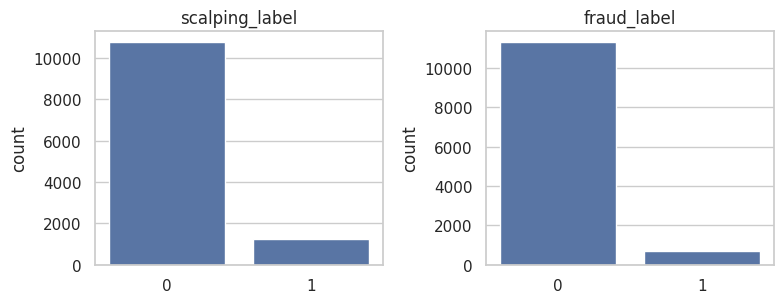

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3.2))
for ax, col in zip(axes, ("scalping_label", "fraud_label")):
    sns.countplot(x=master[col], ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
fig.tight_layout()


### Leakage check

`risk_score` is **derived from** the same labelling function as
`scalping_label` / `fraud_label` — using it as a feature would leak the
target into training and yield artificially perfect models. Same for
the labels themselves and the high-cardinality ID columns. We exclude
all of these in `features.LEAKY_OR_ID_COLS`.


In [7]:
from rexell_ml.features import LEAKY_OR_ID_COLS

# Quick look at the correlation between risk_score and the labels.
print(master[["risk_score", "scalping_label", "fraud_label"]].corr())

print()
print("excluded as features:")
for c in sorted(LEAKY_OR_ID_COLS):
    print(" -", c)


                risk_score  scalping_label  fraud_label
risk_score        1.000000        0.759937     0.928694
scalping_label    0.759937        1.000000     0.492330
fraud_label       0.928694        0.492330     1.000000

excluded as features:
 - event_id
 - fraud_label
 - ip_hash
 - risk_score
 - scalping_label
 - timestamp
 - transaction_hash
 - wallet_address


### Markup / price distributions split by `scalping_label`


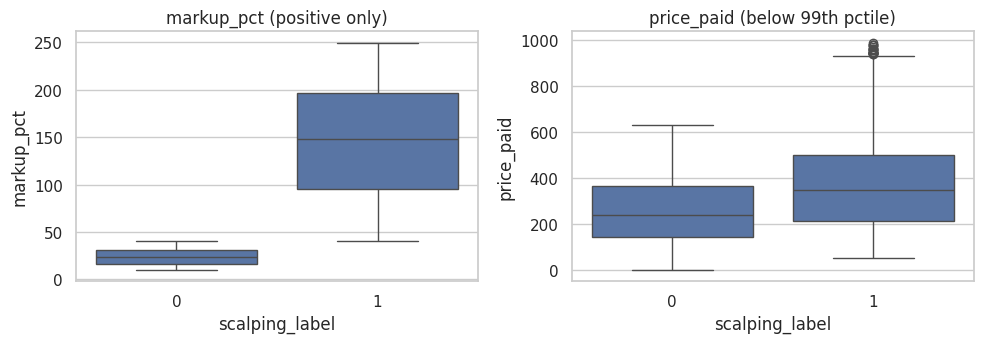

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))

sns.boxplot(
    data=master[master["markup_pct"] > 0],
    x="scalping_label",
    y="markup_pct",
    ax=axes[0],
)
axes[0].set_title("markup_pct (positive only)")

sns.boxplot(
    data=master[master["price_paid"] < master["price_paid"].quantile(0.99)],
    x="scalping_label",
    y="price_paid",
    ax=axes[1],
)
axes[1].set_title("price_paid (below 99th pctile)")

fig.tight_layout()


### Time-of-day pattern


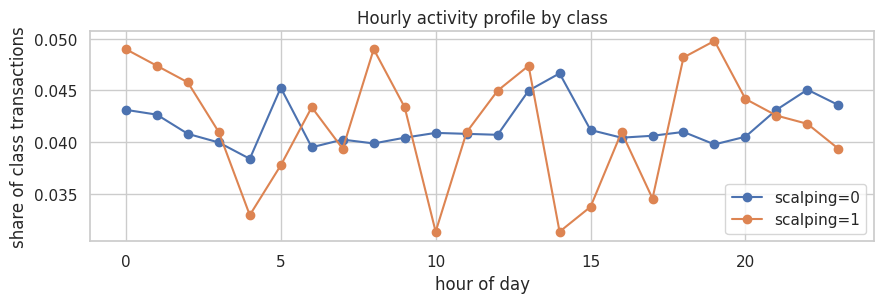

In [9]:
master["timestamp"] = pd.to_datetime(master["timestamp"], errors="coerce")
master["hour"] = master["timestamp"].dt.hour

fig, ax = plt.subplots(figsize=(9, 3.2))
for label in (0, 1):
    sub = master[master["scalping_label"] == label]
    counts = sub.groupby("hour").size() / max(len(sub), 1)
    ax.plot(counts.index, counts.values, marker="o", label=f"scalping={label}")
ax.set_xlabel("hour of day")
ax.set_ylabel("share of class transactions")
ax.set_title("Hourly activity profile by class")
ax.legend()
fig.tight_layout()


## Synthetic user-level CSV


In [10]:
users = data.load_synthetic_user()
print("rows / cols:", users.shape)
users.head()


rows / cols: (5000, 12)


,user_id,age,location,device,account_age_days,event_demand,ticket_price,purchase_time_sec,resale_price,resale_flag,scalper,purchase_date
0,user_306,24,Hyderabad,Mobile,445,Medium,2000,90.30,2000.0,0,0,2024-07-07
1,user_178,38,Mumbai,Tablet,624,Medium,1500,17.71,1500.0,0,0,2024-03-28
2,user_110,38,Pune,Desktop,109,Low,1500,4.62,1500.0,0,0,2024-11-04
3,user_80,19,Pune,Tablet,353,Medium,1500,53.59,1500.0,0,0,2024-07-10
4,user_126,38,Hyderabad,Mobile,170,High,500,10.88,500.0,0,0,2024-08-23


In [11]:
users.dtypes


user_id                      object
age                           int64
location                     object
device                       object
account_age_days              int64
event_demand                 object
ticket_price                  int64
purchase_time_sec           float64
resale_price                float64
resale_flag                   int64
scalper                       int64
purchase_date        datetime64[ns]
dtype: object

In [12]:
users["scalper"].value_counts(normalize=True)


scalper
0    0.9512
1    0.0488
Name: proportion, dtype: float64

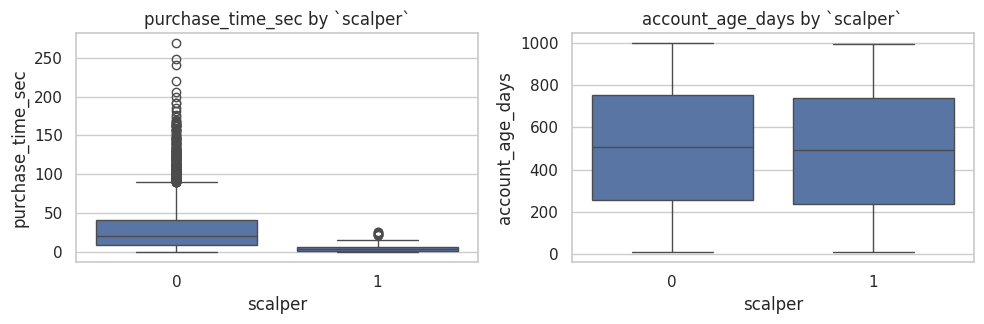

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
sns.boxplot(data=users, x="scalper", y="purchase_time_sec", ax=axes[0])
axes[0].set_title("purchase_time_sec by `scalper`")

sns.boxplot(data=users, x="scalper", y="account_age_days", ax=axes[1])
axes[1].set_title("account_age_days by `scalper`")
fig.tight_layout()


### Categorical columns


In [14]:
for col in ("device", "location", "event_demand"):
    tbl = pd.crosstab(users[col], users["scalper"], normalize="index")
    tbl.columns = [f"scalper={c}" for c in tbl.columns]
    print(f"--- {col} ---")
    print(tbl.round(3))
    print()


--- device ---
         scalper=0  scalper=1
device                       
Desktop      0.949      0.051
Mobile       0.957      0.043
Tablet       0.947      0.053

--- location ---
           scalper=0  scalper=1
location                       
Bangalore      0.953      0.047
Delhi          0.949      0.051
Hyderabad      0.956      0.044
Mumbai         0.947      0.053
Pune           0.950      0.050

--- event_demand ---
              scalper=0  scalper=1
event_demand                      
High              0.956      0.044
Low               0.949      0.051
Medium            0.949      0.051



## Feature builders — sanity preview

The feature engineering notebook (`02_feature_engineering.ipynb`) builds
the production `FeatureVector` from these CSVs. For now, just confirm
the builders run end-to-end and surface a usable label column.


In [15]:
master_feats = features.build_master_features(master)
user_feats   = features.build_synthetic_user_features(users)

print("master features:", master_feats.shape, "  pos pct:", round(master_feats["label"].mean(), 4))
print("user features  :", user_feats.shape,   "  pos pct:", round(user_feats["label"].mean(), 4))
master_feats.head()


master features: (4282, 32)   pos pct: 0.0163
user features  : (5000, 25)   pos pct: 0.0488


,wallet_address,tx_count,purchase_count,resale_count,failure_count,ticket_count_sum,ticket_count_mean,ticket_count_max,ticket_count_std,price_paid_mean,price_paid_std,price_paid_max,markup_pct_mean,markup_pct_std,markup_pct_max,high_markup_ratio,unique_events,unique_ips,ip_entropy,event_entropy,active_hours,active_dows,hour_entropy,session_span_hours,tx_per_hour,min_inter_tx_seconds,mean_inter_tx_seconds,burstiness,purchase_resale_ratio,max_tickets_per_event,events_with_resale,label
0,0x4ac429ec22574039a5d1bbf8f8e3b18b,6,6,0,0,12,2.000000,4,1.095445,275.000000,139.187643,456.0,0.0,0.0,0.0,0.0,6,6,2.584963,2.584963,6,4,2.584963,1254.156110,0.004784,1.860870e+05,9.029924e+05,0.0,6.0,4,0,0
1,0xdc5c8632d1434698b31d21c1785a2d2b,4,4,0,0,13,3.250000,4,0.957427,313.250000,170.913965,466.0,0.0,0.0,0.0,0.0,4,4,2.000000,2.000000,4,3,2.000000,1307.910832,0.003058,5.923300e+05,1.569493e+06,0.0,4.0,4,0,0
2,0xfd8346ff63bf4c21a1bfc80cf5371c4d,47,0,0,17,511,10.872340,20,5.105909,253.978723,114.533931,474.0,0.0,0.0,0.0,0.0,31,47,5.554589,4.783000,22,7,4.110455,1275.515554,0.036848,6.055994e+03,9.982296e+04,0.0,0.0,50,0,1
3,0x1efe997d08934f5da015f235583378e2,4,4,0,0,12,3.000000,4,1.414214,306.750000,88.288825,363.0,0.0,0.0,0.0,0.0,4,4,2.000000,2.000000,4,2,2.000000,851.613054,0.004697,5.094299e+04,1.021936e+06,0.0,4.0,4,0,0
4,0x2961501270c44dd388b8f4e5bd092018,3,3,0,0,8,2.666667,4,1.154701,143.666667,54.307765,177.0,0.0,0.0,0.0,0.0,3,3,1.584963,1.584963,3,3,1.584963,940.049167,0.003191,1.660388e+06,1.692088e+06,0.0,3.0,4,0,0


## Conclusions

- Both targets are imbalanced (≈1.6 % wallet-level scalpers in the master CSV,
  ≈4.9 % scalpers in the user-level synthetic CSV) → use stratified splitting,
  class weighting and tune thresholds for `<2 %` FPR (Property 8).
- `risk_score` is a derived label and **must not** be used as a feature.
  The aggregator excludes it along with all transaction IDs.
- There is a clear time-of-day signal and visible markup/price gaps between
  classes → tabular tree models should already perform well; the deep
  models are an independent check.

Continue to **`02_feature_engineering.ipynb`** to materialise the 30-dim
feature vector and persist train / val / test parquet splits.
